## Methodological guardrails

1. A high score is not proof that an intersection is inherently dangerous.
2. Current predictions are not exposure-normalized because pedestrian and vehicle volumes are not yet directly included.
3. Current-week crash history and current-week weather are used to predict the following week.
4. Training, validation, and test periods are chronological.
5. Model selection, threshold tuning, and ablation comparisons use the validation period.
6. The test period is evaluated only after the baseline model and threshold are locked.
7. Feature importance does not establish causation.
8. Engineering recommendations require external road-safety evidence and site review.

## Required Notebook 1 files

Place these files in the Colab folders shown below:

```text
/content/
├── data/
│   ├── processed/
│   │   └── safecross_event_level_dataset*.parquet
│   └── raw/
│       ├── osm_drive_*.graphml
│       └── weather_hourly_*.csv
```


**This is Notebook 2** — data loading through model training, evaluation, and saving the final model. Notebook 3 picks up from the saved model and does not require Notebook 1 or Notebook 2 to be re-run.

# 1. Install packages

In [1]:
# Install (quietly) the libraries this notebook depends on: data handling (pandas/numpy),
# plotting (matplotlib), street-network tools (osmnx/networkx), fast columnar I/O (pyarrow),
# modeling (scikit-learn), model persistence (joblib), and interactive maps (folium).
%pip install -q pandas numpy matplotlib osmnx networkx pyarrow scikit-learn joblib folium xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


# 2. Imports and reproducibility settings

In [2]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path
from typing import Any

import folium
import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# XGBoost gives a gradient-boosted-tree option to compare against logistic
# regression and random forest; it's imported separately since it isn't
# part of scikit-learn itself.
from xgboost import XGBClassifier

# LightGBM is a second, independently-implemented gradient-boosting library —
# comparing it against XGBoost checks whether "gradient boosting works well
# here" is a robust finding, or just an artifact of one specific library.
from lightgbm import LGBMClassifier

# MLPClassifier is a small feed-forward neural network, included as a model
# family that works completely differently from every tree-based model above
# (no splits/thresholds — it learns smooth, weighted combinations of inputs).
from sklearn.neural_network import MLPClassifier

# FutureWarning noise from library version churn just clutters notebook output,
# so it's suppressed here (this doesn't hide real errors, only future-deprecation notices).
warnings.filterwarnings("ignore", category=FutureWarning)

# A fixed random seed makes anything involving randomness (model training,
# sampling, shuffling) reproducible from run to run.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Record the exact library versions used, so results here can be reproduced
# later even if the environment/dependencies change.
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("OSMnx:", ox.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.0
pandas: 3.0.5
OSMnx: 2.1.1
scikit-learn: 1.9.0


# 3. Configuration

The default settings build the intersection-week analysis for whatever scope Notebook 1 saved. With the full-history, citywide Notebook 1 output this is every eligible OSM intersection in all five boroughs for every complete week from mid-2012 onward.

### Scale: what changed compared with the Manhattan version

The panel has one row per eligible intersection per complete week. For the full history that is on the order of **tens of millions of rows**, so several parts of this notebook were rewritten to fit in 32 GB of RAM and finish in a reasonable time on a CPU:

1. **The panel is built as NumPy matrices** (intersections x weeks) instead of a giant pandas table with merges and `groupby().rolling()`. The rolling features are computed with cumulative sums. These produce the same numbers as the original pandas code (checked on synthetic data).
2. **Features are stored as `float32`.**
3. **Training negatives are downsampled** (`TRAIN_NEGATIVE_SAMPLE_FRACTION`). Every positive row is kept; only a random fraction of the zero-crash training rows is kept. **Validation and test are never downsampled**, so thresholds, metrics, and rankings are computed on the real class balance.
4. **Random forest and the MLP train on a capped subsample** (`SLOW_MODEL_TRAIN_ROWS`) because they scale poorly.
5. **The threshold search uses one precision-recall curve** instead of calling scikit-learn once per unique predicted probability (which would take days at this size).

### Important timing definition

A row for week \(t\) uses crash history, road features, seasonality, and weather observed through the end of week \(t\). The target describes whether a crash occurs during week \(t+1\).

Therefore, weather from week \(t\) is valid. It should not be shifted back an additional week.

In [3]:
# Sets thi to a repository folder only when the project is not stored in /content.
# On Colab, leave this as None so choose_repo_root() auto-detects /content.
REPO_ROOT_OVERRIDE = None

# Optional exact paths. Leave as None to use the filename patterns below.
EVENT_DATA_PATH_OVERRIDE = None
OSM_GRAPH_PATH_OVERRIDE = None
WEATHER_DATA_PATH_OVERRIDE = None

# Optional date limits such as "2024-01-01" and "2024-12-31".
# When left as None, the continuous weather file defines the analysis coverage.
ANALYSIS_START_DATE = None
ANALYSIS_END_DATE = None

CANDIDATE_MIN_STREET_COUNT = 3
MAX_NODE_MATCH_DISTANCE_M = 75.0

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

THRESHOLD_BETA = 2.0
RF_N_ESTIMATORS = 100          # random forest trees (memory-heavy at this scale)
LGBM_N_ESTIMATORS = 200
XGB_N_ESTIMATORS = 200

# --- Scale controls for the full-history run ---
# Keep every positive training row but only this fraction of zero-crash training rows.
# Validation and test are NEVER downsampled. Set to 1.0 to train on everything.
TRAIN_NEGATIVE_SAMPLE_FRACTION = 0.25
# Random forest and the MLP are trained on at most this many (already downsampled) rows.
SLOW_MODEL_TRAIN_ROWS = 1_000_000
# Writing the full panel to parquet takes many GB and nothing downstream reads it.
SAVE_MODELING_PANEL = False
PERMUTATION_SAMPLE_ROWS = 10_000
PERMUTATION_REPEATS = 5

assert np.isclose(TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION, 1.0)

print("Minimum street count:", CANDIDATE_MIN_STREET_COUNT)
print("Maximum crash-to-node distance:", MAX_NODE_MATCH_DISTANCE_M, "m")

Minimum street count: 3
Maximum crash-to-node distance: 75.0 m


# 4. Colab-safe project paths


In [4]:
def choose_repo_root() -> Path:
    # Manual override will take over if the User sets one.
    if REPO_ROOT_OVERRIDE is not None:
        return Path(REPO_ROOT_OVERRIDE).expanduser().resolve()

    # Google Colab convention: project files live under /content, and the
    # runtime's cwd is often "/" itself. Either signal means "we're on Colab".
    colab_root = Path("/content")
    current = Path.cwd()
    if (colab_root / "data").exists() or current == Path("/"):
        return colab_root

    # If the notebook is being run from inside a "notebooks" folder, the
    # actual project root is one level up.
    if current.name.lower() == "notebooks":
        return current.parent

    # Otherwise assume cwd already is the repo root.
    return current


REPO_ROOT = choose_repo_root()

# Define subfolders relative to the calculated repo root
DATA_RAW_DIR = REPO_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "models"
METRIC_DIR = REPO_ROOT / "reports" / "metrics"
NOTEBOOK_OUTPUT_DIR = REPO_ROOT / "reports" / "notebook_02_03"
# Creates all of the folders specified above
for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, MODEL_DIR, METRIC_DIR, NOTEBOOK_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# Used to find the latest edited file from a directory
# Useful if the program creates new files everytime it runs
# We only want the most recent
def newest_matching_file(directory: Path, pattern: str, required: bool = True) -> Path | None:
    if not directory.exists():
        if required:
            raise FileNotFoundError(f"Required folder does not exist: {directory}")
        return None

    matches = [path for path in directory.glob(pattern) if path.is_file()]

    if not matches:
        if required:
            raise FileNotFoundError(f"No file matching '{pattern}' was found in:\n{directory}\n\n" "Run Notebook 1 completely or upload the missing file.")
        return None

    return max(matches, key=lambda path: path.stat().st_mtime)


# The next 3 blocks use the manual override if one is given
# If not they use the most recent version of the file
# They are the files that are inputted
EVENT_DATA_PATH = Path(EVENT_DATA_PATH_OVERRIDE) if EVENT_DATA_PATH_OVERRIDE else newest_matching_file(DATA_PROCESSED_DIR, "safecross_event_level_dataset*.parquet")

OSM_GRAPH_PATH = Path(OSM_GRAPH_PATH_OVERRIDE) if OSM_GRAPH_PATH_OVERRIDE else newest_matching_file(DATA_RAW_DIR, "osm_drive_*.graphml")

WEATHER_DATA_PATH = Path(WEATHER_DATA_PATH_OVERRIDE) if WEATHER_DATA_PATH_OVERRIDE else newest_matching_file(DATA_RAW_DIR, "weather_hourly_*.csv")
# Prints out the roots
print("Repository root:", REPO_ROOT)
print("Event data:", EVENT_DATA_PATH)
print("OSM graph:", OSM_GRAPH_PATH)
print("Weather data:", WEATHER_DATA_PATH)

Repository root: c:\Users\j9936\Desktop\Capstone\noteboooks
Event data: c:\Users\j9936\Desktop\Capstone\noteboooks\data\processed\safecross_event_level_dataset_nyc_all.parquet
OSM graph: c:\Users\j9936\Desktop\Capstone\noteboooks\data\raw\osm_drive_nyc_all.graphml
Weather data: c:\Users\j9936\Desktop\Capstone\noteboooks\data\raw\weather_hourly_nyc_all_2012-07-01_2026-05-12.csv


# 5. Load and validate Notebook 1 data

In [5]:
# Load the three datasets we located earlier.
# pd.read_parquet / pd.read_csv return pandas DataFrames (table-like objects).
# Only load the columns this notebook uses. The event file has many text columns that
# would otherwise add gigabytes of memory at full-history scale.
EVENT_LOAD_COLUMNS = [
    "collision_id", "crash_datetime", "nearest_osm_node", "distance_to_osm_node_m",
    "number_of_persons_injured", "number_of_persons_killed", "pedestrian_casualty", "cyclist_casualty",
]
events = pd.read_parquet(EVENT_DATA_PATH, columns=EVENT_LOAD_COLUMNS)
# ox = the osmnx library, used for working with street/road network data
# pulled from OpenStreetMap. load_graphml reads that network back into
# a graph object (nodes = intersections/points, edges = road segments)
street_graph = ox.io.load_graphml(OSM_GRAPH_PATH)
weather = pd.read_csv(WEATHER_DATA_PATH)

# These are columns that the rest of the notebook will assume exist
REQUIRED_EVENT_COLUMNS = [
    "collision_id",
    "crash_datetime",
    "nearest_osm_node",
    "distance_to_osm_node_m",
    "number_of_persons_injured",
    "number_of_persons_killed",
    "pedestrian_casualty",
    "cyclist_casualty",
]
# These are the columns that are required but don't exist
missing_event_columns = [column for column in REQUIRED_EVENT_COLUMNS if column not in events.columns]
# Tells what required columsn are missing
if missing_event_columns:
    raise ValueError("The event dataset is missing required columns: " + ", ".join(missing_event_columns))
# This standardizes all of the timestamp collumns to "Weather_Hour"
if "weather_hour" not in weather.columns:
    timestamp_candidates = [column for column in weather.columns if column.lower() in {"time", "datetime", "date"}]
    if not timestamp_candidates:
        raise ValueError("No recognizable weather timestamp column was found.")
    weather["weather_hour"] = weather[timestamp_candidates[0]]
# Converts to actual datetime object so it can be compared
events["crash_datetime"] = pd.to_datetime(events["crash_datetime"], errors="coerce")
# Forces all values to become nullable strings
events["nearest_osm_node"] = events["nearest_osm_node"].astype("string")
events["distance_to_osm_node_m"] = pd.to_numeric(events["distance_to_osm_node_m"], errors="coerce")

weather["weather_hour"] = pd.to_datetime(weather["weather_hour"], errors="coerce")
# dropna removes any rows that have missing values in the subset
events = events.dropna(subset=["collision_id", "crash_datetime", "nearest_osm_node", "distance_to_osm_node_m"]).drop_duplicates(subset=["collision_id"]).copy()
# same as one above
weather = weather.dropna(subset=["weather_hour"]).copy()
# Checks if the dataset has any rows to make sure we didn't
# delete everything
if events.empty:
    raise ValueError("The cleaned event dataset contains no rows.")

if weather.empty:
    raise ValueError("The cleaned weather dataset contains no rows.")

if street_graph.number_of_nodes() == 0:
    raise ValueError("The OSM graph contains no nodes.")
# The ":" formats the numbers with comma's for ease of reading
print("Clean event rows:", f"{len(events):,}")
print("Weather rows:", f"{len(weather):,}")
print("OSM nodes:", f"{street_graph.number_of_nodes():,}")
print("OSM edges:", f"{street_graph.number_of_edges():,}")

C:\Users\j9936\AppData\Local\Temp\ipykernel_31176\1425932597.py:14: DtypeWarning: Columns (0: station) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv(WEATHER_DATA_PATH)


Clean event rows: 2,013,992
Weather rows: 121,536
OSM nodes: 55,339
OSM edges: 139,195


# 6. Define the analysis coverage

Crash-event data cannot reliably define the first and last observation dates because days with no crashes do not appear as rows. The hourly weather file is continuous, so it provides the default observation window.

Only complete Monday-through-Sunday weeks are retained.

In [6]:
# .min() and .max() find the earliest and latest timestamps in weather data
# .normalize takes out time of day data and sets them all to midnight
weather_start = weather["weather_hour"].min().normalize()
weather_end = weather["weather_hour"].max().normalize()

# Use a specified start date is specified if one was given
# Else use the earliest date in the data
analysis_start = pd.Timestamp(ANALYSIS_START_DATE).normalize() if ANALYSIS_START_DATE is not None else weather_start
# Same as above except for the end
analysis_end = pd.Timestamp(ANALYSIS_END_DATE).normalize() if ANALYSIS_END_DATE is not None else weather_end
# Checks that the data makes sense with the end being after the start
if analysis_end <= analysis_start:
    raise ValueError("The analysis end date must be after the start date.")
# This makes all of the data points sit between the start and end date
# .between() checks each value against the specified range
# The analysis_end + 1 day to make both of the dates inclusive
events = events.loc[events["crash_datetime"].between(analysis_start, analysis_end + pd.Timedelta(days=1), inclusive="left")].copy()

weather = weather.loc[weather["weather_hour"].between(analysis_start, analysis_end + pd.Timedelta(days=1), inclusive="left")].copy()

# Now we are figuring out which full monday-sunday weeks are filled out
# .dayofweek gives 0 for monday and 6 for sunday
# This computes the amount of offset to give to analysis_start
# to start on a monday
days_until_monday = (-analysis_start.dayofweek) % 7
first_complete_week = analysis_start + pd.Timedelta(days=days_until_monday)
# find the monday of the week that analysis_end falls in
last_week_candidate = analysis_end - pd.Timedelta(days=analysis_end.dayofweek)
# if the last week isn't fully covered,
# shift back one week
if analysis_end < last_week_candidate + pd.Timedelta(days=6):
    last_complete_week = last_week_candidate - pd.Timedelta(days=7)
else:
    last_complete_week = last_week_candidate
# builds a list of all the fully complete week
all_weeks = pd.date_range(first_complete_week, last_complete_week, freq="7D")
# Makes sure that the span is longer than 16 weeks
if len(all_weeks) < 16:
    raise ValueError(f"Only {len(all_weeks)} complete weeks are available. " "Use a longer date range.")
# Prints out variables to show that it has worked
print("Analysis start:", analysis_start.date())
print("Analysis end:", analysis_end.date())
print("First complete week:", first_complete_week.date())
print("Last complete week:", last_complete_week.date())
print("Complete observed weeks:", len(all_weeks))
print("Usable target weeks after next-week shifting:", len(all_weeks) - 1)

Analysis start: 2012-07-01
Analysis end: 2026-05-12
First complete week: 2012-07-02
Last complete week: 2026-05-04
Complete observed weeks: 723
Usable target weeks after next-week shifting: 722


# 7. Apply the crash-to-node distance filter

In [7]:
# Only keep nodes that are close enough to a OSM intersection

events_near_nodes = events.loc[events["distance_to_osm_node_m"] <= MAX_NODE_MATCH_DISTANCE_M].copy()
# If the filter completely wipes out every node,
# We know something went wrong and we need to stop it
if events_near_nodes.empty:
    raise ValueError("No crash records remain after the node-distance filter.")
# building a table to display the results of the filtering
distance_summary = pd.Series(
    {
        "clean_events": len(events),
        "events_within_threshold": len(events_near_nodes),
        "retained_fraction": len(events_near_nodes) / len(events),
        "median_match_distance_m": (events_near_nodes["distance_to_osm_node_m"].median()),
        "p95_match_distance_m": (events_near_nodes["distance_to_osm_node_m"].quantile(0.95)),
    },
    name="value",
)

display(distance_summary.to_frame())

,value
clean_events,2.013992e+06
events_within_threshold,1.889976e+06
retained_fraction,9.384228e-01
median_match_distance_m,1.776732e+00
p95_match_distance_m,5.239542e+01


# 8. Build the eligible intersection set

In [8]:
# For every node in the network, count how many street
# Segments connect to it. This gives us whether or not
# It is a 4-way or 3-way intersection
# street_count is the variable
street_count_by_node = ox.stats.count_streets_per_node(street_graph)
# nx = networkx, the thing osmnx is built on
nx.set_node_attributes(street_graph, street_count_by_node, "street_count")
# Turns the street_graph into a GeoDataFrame
# This makes filtering and operating on it
# Much easier. Edges are kept (not discarded) because road-design features
# like lanes, speed limit, and road class live on edges, not nodes.
nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(street_graph, nodes=True, edges=True)
# graph_to_gdps() makes node ID the DataFrame Index
# reset_index() makes the Index column a normal column
# Which is useful for operating on it
nodes = nodes_gdf.reset_index().copy()

# The id column is usually called osmid
node_id_column = "osmid" if "osmid" in nodes.columns else nodes.columns[0]

# Makes column_id as the id column name and makes it into a string
nodes = nodes.rename(columns={node_id_column: "node_id"})
nodes["node_id"] = nodes["node_id"].astype("string")
# errors=coerce tells the program that if an error occurs, simply add NaN
# makes sure street_count(intersection amount) is a number
nodes["street_count"] = pd.to_numeric(nodes["street_count"], errors="coerce")

# renames x and y coordinates to longitude and latitude
nodes["longitude"] = pd.to_numeric(nodes["x"], errors="coerce")
nodes["latitude"] = pd.to_numeric(nodes["y"], errors="coerce")

# usually osm will have highway and crossing labels
# if not, we add them as empty columns
if "highway" not in nodes.columns:
    nodes["highway"] = pd.NA

if "crossing" not in nodes.columns:
    nodes["crossing"] = pd.NA

# makes node_highway column into highway
# and forces all of the values to be strings
nodes["node_highway"] = nodes["highway"].astype("string").fillna("missing")
# Flags nodes that contain traffic signals
# str.contains checks all of the values for that string
# case=False makes it not case sensitive
# na=False makes it so that a missing value is treated as False
# astype() makes True/False into 1/0
nodes["is_traffic_signal"] = nodes["node_highway"].str.contains("traffic_signals", case=False, na=False).astype("int8")

# Flags nodes that have an existing traffic tag(regardless of value)
# .notna() checks if the tag is present(stored as 1/0 for True/False)
nodes["is_crossing_tagged"] = nodes["crossing"].notna().astype("int8")
# Filters out and nodes with a street_count of 3 or higher
candidate_nodes = (
    nodes.loc[nodes["street_count"] >= CANDIDATE_MIN_STREET_COUNT, ["node_id", "latitude", "longitude", "street_count", "node_highway", "is_traffic_signal", "is_crossing_tagged"]]
    .dropna(subset=["node_id", "latitude", "longitude"])
    .drop_duplicates(subset=["node_id"])
    .copy()
)

if candidate_nodes.empty:
    raise ValueError("No eligible intersection nodes were found.")

print("All OSM nodes:", f"{len(nodes):,}")
print("Eligible candidate intersections:", f"{len(candidate_nodes):,}")

display(candidate_nodes.head())

All OSM nodes: 55,339
Eligible candidate intersections: 51,270


,node_id,latitude,longitude,street_count,node_highway,is_traffic_signal,is_crossing_tagged
0,39076461,40.786345,-73.794748,3,motorway_junction,0,0
1,39076490,40.762429,-73.757091,3,motorway_junction,0,0
2,39076504,40.753467,-73.744164,3,motorway_junction,0,0
3,42421728,40.798048,-73.960044,3,traffic_signals,1,0
4,42421731,40.798654,-73.961474,4,traffic_signals,1,0


# 8b. Audit and add road-design features

Crash history alone doesn't explain *why* an intersection is risky. Before adding road-design tags from OSM (road class, lanes, speed limit, one-way, traffic signals, crossings) as model features, each tag's completeness is checked first — a tag that's missing on most nodes/edges isn't a reliable feature no matter how relevant it sounds. Only tags at or above `FEATURE_COMPLETENESS_THRESHOLD` are used; everything else is documented here and left out.

In [9]:
# --- Missingness audit for candidate road-design tags ---
# Before adding any of these as model features, check how often each tag is
# actually present in this graph. A tag that's missing on most
# nodes/edges isn't a reliable feature no matter how useful it sounds.

# Node-level tags (attached to intersections themselves)
node_candidate_tags = [
    "highway",   # used to detect stop signs / traffic signals
    "crossing",  # crosswalk presence/type
    "junction",  # roundabout / circular junction type
]

# Edge-level tags (attached to the road segments connecting nodes)
edge_candidate_tags = [
    "highway",   # road class (residential, primary, tertiary, etc.)
    "lanes",     # number of lanes
    "maxspeed",  # speed limit
    "oneway",    # one-way vs two-way
    "junction",  # roundabout tag sometimes lives on edges instead of nodes
]

total_nodes_for_audit = len(nodes_gdf)
total_edges_for_audit = len(edges_gdf)


def tag_missingness(frame, tag, total):
    # A tag can be entirely absent as a column, or present but NaN/None for
    # some rows — both count as "missing" for deciding whether to use it.
    if tag not in frame.columns:
        return {"tag": tag, "present_as_column": False, "non_null_pct": 0.0}
    non_null = frame[tag].notna().sum()
    return {
        "tag": tag,
        "present_as_column": True,
        "non_null_pct": round(100 * non_null / total, 2),
    }


node_missingness = pd.DataFrame([tag_missingness(nodes_gdf, tag, total_nodes_for_audit) for tag in node_candidate_tags])
node_missingness.insert(0, "level", "node")

edge_missingness = pd.DataFrame([tag_missingness(edges_gdf, tag, total_edges_for_audit) for tag in edge_candidate_tags])
edge_missingness.insert(0, "level", "edge")

missingness_report = pd.concat([node_missingness, edge_missingness], ignore_index=True).sort_values(["level", "non_null_pct"], ascending=[True, False])

# Only tags at or above this completeness level are trusted enough to become
# model features. Anything below this is documented here but left out —
# per the project rule of not adding features just because they sound useful.
FEATURE_COMPLETENESS_THRESHOLD = 0.50

print(f"Total nodes: {total_nodes_for_audit:,}  |  Total edges: {total_edges_for_audit:,}")
print(f"Completeness threshold for use as a feature: {FEATURE_COMPLETENESS_THRESHOLD:.0%}")
display(missingness_report)

Total nodes: 55,339  |  Total edges: 139,195
Completeness threshold for use as a feature: 50%


,level,tag,present_as_column,non_null_pct
3,edge,highway,True,100.00
6,edge,oneway,True,100.00
4,edge,lanes,True,33.74
5,edge,maxspeed,True,30.97
7,edge,junction,True,0.18
0,node,highway,True,32.31
2,node,junction,True,0.02
1,node,crossing,False,0.00


In [10]:
# --- Build road-design features, keeping only the ones that cleared the
#     completeness threshold above ---

usable_edge_tags = set(
    missingness_report.loc[(missingness_report["level"] == "edge") & (missingness_report["non_null_pct"] >= FEATURE_COMPLETENESS_THRESHOLD * 100), "tag"]
)
usable_node_tags = set(
    missingness_report.loc[(missingness_report["level"] == "node") & (missingness_report["non_null_pct"] >= FEATURE_COMPLETENESS_THRESHOLD * 100), "tag"]
)

print("Usable edge tags:", sorted(usable_edge_tags))
print("Usable node tags:", sorted(usable_node_tags))

# Edge geometries reference their endpoints as "u" and "v" node ids in the
# GeoDataFrame index; reset_index() pulls those into normal columns so we can
# group by node like any other table.
edges_for_features = edges_gdf.reset_index()

road_design_features = pd.DataFrame({"node_id": nodes["node_id"]})

if "highway" in usable_edge_tags:
    # A node can have several connecting edges of different classes (e.g. a
    # residential street meeting an arterial); take the "highest" class among
    # them, since that's usually the more relevant one for crash risk.
    ROAD_CLASS_RANK = {"motorway": 6, "trunk": 5, "primary": 4, "secondary": 3, "tertiary": 2, "residential": 1, "unclassified": 0, "service": 0}

    def road_class_rank(value):
        if isinstance(value, list):
            value = value[0] if value else None
        return ROAD_CLASS_RANK.get(value, -1)

    edges_for_features["road_class_rank"] = edges_for_features["highway"].apply(road_class_rank)

    highest_class_per_endpoint = pd.concat(
        [
            edges_for_features[["u", "highway", "road_class_rank"]].rename(columns={"u": "node_id"}),
            edges_for_features[["v", "highway", "road_class_rank"]].rename(columns={"v": "node_id"}),
        ]
    )
    highest_class_per_endpoint["node_id"] = highest_class_per_endpoint["node_id"].astype("string")

    best_road_class = highest_class_per_endpoint.sort_values("road_class_rank", ascending=False).drop_duplicates(subset="node_id")

    road_design_features = road_design_features.merge(
        best_road_class[["node_id", "highway"]].rename(columns={"highway": "road_class"}), on="node_id", how="left"
    )

if "lanes" in usable_edge_tags:
    # A node's most demanding connecting road is what a pedestrian actually
    # has to cross, so use the maximum lane count among connecting edges.
    def parse_lanes(value):
        if isinstance(value, list):
            value = value[0] if value else None
        return pd.to_numeric(value, errors="coerce")

    edges_for_features["lanes_numeric"] = edges_for_features["lanes"].apply(parse_lanes)

    lanes_per_endpoint = pd.concat(
        [
            edges_for_features[["u", "lanes_numeric"]].rename(columns={"u": "node_id"}),
            edges_for_features[["v", "lanes_numeric"]].rename(columns={"v": "node_id"}),
        ]
    )
    lanes_per_endpoint["node_id"] = lanes_per_endpoint["node_id"].astype("string")

    max_lanes = lanes_per_endpoint.groupby("node_id", as_index=False)["lanes_numeric"].max().rename(columns={"lanes_numeric": "max_connecting_lanes"})

    road_design_features = road_design_features.merge(max_lanes, on="node_id", how="left")

if "maxspeed" in usable_edge_tags:
    # Take the highest posted speed limit among connecting edges — the fastest
    # approach is generally the more relevant one for crossing risk.
    def parse_speed(value):
        if isinstance(value, list):
            value = value[0] if value else None
        if isinstance(value, str):
            value = "".join(character for character in value if character.isdigit())
        return pd.to_numeric(value, errors="coerce")

    edges_for_features["maxspeed_numeric"] = edges_for_features["maxspeed"].apply(parse_speed)

    speed_per_endpoint = pd.concat(
        [
            edges_for_features[["u", "maxspeed_numeric"]].rename(columns={"u": "node_id"}),
            edges_for_features[["v", "maxspeed_numeric"]].rename(columns={"v": "node_id"}),
        ]
    )
    speed_per_endpoint["node_id"] = speed_per_endpoint["node_id"].astype("string")

    max_speed = speed_per_endpoint.groupby("node_id", as_index=False)["maxspeed_numeric"].max().rename(columns={"maxspeed_numeric": "max_connecting_speed_limit"})

    road_design_features = road_design_features.merge(max_speed, on="node_id", how="left")

if "oneway" in usable_edge_tags:
    # Flag a node as touching a one-way street if ANY connecting edge is
    # tagged one-way — one-way approaches change how pedestrians need to look.
    edges_for_features["is_oneway_numeric"] = edges_for_features["oneway"].astype("string").str.lower().eq("true").astype("int8")

    oneway_per_endpoint = pd.concat(
        [
            edges_for_features[["u", "is_oneway_numeric"]].rename(columns={"u": "node_id"}),
            edges_for_features[["v", "is_oneway_numeric"]].rename(columns={"v": "node_id"}),
        ]
    )
    oneway_per_endpoint["node_id"] = oneway_per_endpoint["node_id"].astype("string")

    touches_oneway = oneway_per_endpoint.groupby("node_id", as_index=False)["is_oneway_numeric"].max().rename(columns={"is_oneway_numeric": "touches_oneway_street"})

    road_design_features = road_design_features.merge(touches_oneway, on="node_id", how="left")

# Node-level tags that were already computed earlier (is_traffic_signal,
# is_crossing_tagged) don't need re-extraction — they're already columns on
# `nodes` / `candidate_nodes` and stay as-is.

ROAD_DESIGN_FEATURE_COLUMNS = [column for column in road_design_features.columns if column != "node_id"]

print("Road-design features that cleared the completeness threshold:", ROAD_DESIGN_FEATURE_COLUMNS)

# Attach these onto candidate_nodes so they flow into the panel the same way
# every other static node attribute does.
candidate_nodes = candidate_nodes.merge(road_design_features, on="node_id", how="left")

display(candidate_nodes.head())

Usable edge tags: ['highway', 'oneway']
Usable node tags: []
Road-design features that cleared the completeness threshold: ['road_class', 'touches_oneway_street']


,node_id,latitude,longitude,street_count,node_highway,is_traffic_signal,is_crossing_tagged,road_class,touches_oneway_street
0,39076461,40.786345,-73.794748,3,motorway_junction,0,0,motorway,1.0
1,39076490,40.762429,-73.757091,3,motorway_junction,0,0,motorway,1.0
2,39076504,40.753467,-73.744164,3,motorway_junction,0,0,motorway,1.0
3,42421728,40.798048,-73.960044,3,traffic_signals,1,0,secondary,0.0
4,42421731,40.798654,-73.961474,4,traffic_signals,1,0,secondary,0.0


# 9. Aggregate retained crashes by intersection and week

In [11]:
# Only keep the set of intersection node IDs we decided were eligible earlier.
eligible_node_ids = set(candidate_nodes["node_id"])

# Keep only crash events whose matched node is one of those eligible intersections.
intersection_events = events_near_nodes.loc[events_near_nodes["nearest_osm_node"].isin(eligible_node_ids)].copy()

# Rename to a consistent "node_id" column name so it matches candidate_nodes.
intersection_events = intersection_events.rename(columns={"nearest_osm_node": "node_id"})

# Fail loudly if nothing survived the eligible-node filter.
if intersection_events.empty:
    raise ValueError("No retained crash records matched eligible intersections.")


# Helper: snap any timestamp back to the Monday that starts its week,
# so events/weather can be grouped into consistent Monday-start weeks.
def monday_week_start(timestamp_series: pd.Series) -> pd.Series:
    normalized = pd.to_datetime(timestamp_series, errors="coerce").dt.normalize()

    return normalized - pd.to_timedelta(normalized.dt.dayofweek, unit="D")


# Tag every retained crash with the Monday of the week it happened in.
intersection_events["week_start"] = monday_week_start(intersection_events["crash_datetime"])

# Columns we'll sum up per intersection-week as crash-severity outcomes.
OUTCOME_COLUMNS = ["number_of_persons_injured", "number_of_persons_killed", "pedestrian_casualty", "cyclist_casualty"]

# Make sure these outcome columns are numeric, treating anything unparseable
# or missing as 0 (i.e. "no injury/fatality/casualty reported").
for column in OUTCOME_COLUMNS:
    intersection_events[column] = pd.to_numeric(intersection_events[column], errors="coerce").fillna(0)

# Collapse individual crash records into one row per (node, week), counting
# unique crashes and summing injuries/casualties for that intersection-week.
weekly_events = intersection_events.groupby(["node_id", "week_start"], as_index=False).agg(
    crash_count=("collision_id", "nunique"),
    persons_injured=("number_of_persons_injured", "sum"),
    persons_killed=("number_of_persons_killed", "sum"),
    pedestrian_casualty_crashes=("pedestrian_casualty", "sum"),
    cyclist_casualty_crashes=("cyclist_casualty", "sum"),
    mean_node_match_distance_m=("distance_to_osm_node_m", "mean"),
)

# Restrict to the weeks we determined are "complete" (fully covered by data).
weekly_events = weekly_events.loc[weekly_events["week_start"].isin(all_weeks)].copy()

print("Retained intersection-area crash events:", f"{len(intersection_events):,}")
print("Positive intersection-week rows:", f"{len(weekly_events):,}")

Retained intersection-area crash events: 1,874,444
Positive intersection-week rows: 1,656,274


# 10. Create the complete intersection-week panel

A crash-only table contains only positive events. It cannot support a valid binary classifier by itself.

The complete panel includes every eligible intersection during every complete observed week. Intersection-weeks without a retained crash receive a crash count of zero.

**Implementation note:** because every intersection has every week, the panel is a complete rectangle. It is stored here as matrices with one row per intersection and one column per week. This is far lighter than a pandas table with tens of millions of rows, and it makes the rolling-window features in section 12 simple cumulative sums. The long-format table that the models use is assembled in section 13.

In [12]:
# --- Complete intersection x week panel, stored as (intersections x weeks) matrices ---
# Every eligible intersection gets every complete week, including weeks with zero
# crashes, since "no crash happened" is meaningful data, not missing data.

node_ids = candidate_nodes["node_id"].to_numpy()
N_NODES = len(node_ids)
N_WEEKS = len(all_weeks)

# Lookup tables: node id -> row number, week start -> column number.
node_position = pd.Series(np.arange(N_NODES), index=pd.Index(node_ids))
week_position = pd.Series(np.arange(N_WEEKS), index=pd.DatetimeIndex(all_weeks))

event_rows = node_position.reindex(weekly_events["node_id"].to_numpy()).to_numpy()
event_cols = week_position.reindex(pd.DatetimeIndex(weekly_events["week_start"])).to_numpy()

# Every retained crash-week must land on a known intersection and a known week.
assert not np.isnan(event_rows).any(), "A crash-week mapped to an unknown intersection."
assert not np.isnan(event_cols).any(), "A crash-week mapped to an unknown week."
event_rows = event_rows.astype(np.int64)
event_cols = event_cols.astype(np.int64)

# Each (node, week) pair must appear at most once.
event_keys = event_rows * N_WEEKS + event_cols
assert len(np.unique(event_keys)) == len(event_keys), "Duplicate intersection-week rows."

# Crash/casualty counts default to 0 (not missing) for weeks with no matching crash.
COUNT_COLUMNS = ["crash_count", "persons_injured", "persons_killed", "pedestrian_casualty_crashes", "cyclist_casualty_crashes"]

count_arrays = {}
for column in COUNT_COLUMNS:
    matrix = np.zeros((N_NODES, N_WEEKS), dtype=np.int32)
    matrix[event_rows, event_cols] = weekly_events[column].to_numpy()
    count_arrays[column] = matrix

# --- Structural sanity checks ---
assert count_arrays["crash_count"].shape == (N_NODES, N_WEEKS)
assert count_arrays["crash_count"].sum() == weekly_events["crash_count"].sum()
# Zero-crash weeks must exist, otherwise the panel isn't representing "nothing happened".
assert (count_arrays["crash_count"] == 0).any()

total_cells = N_NODES * N_WEEKS
zero_cells = int((count_arrays["crash_count"] == 0).sum())
print("Eligible intersections:", f"{N_NODES:,}")
print("Complete weeks:", f"{N_WEEKS:,}")
print("Panel rows (intersection-weeks):", f"{total_cells:,}")
print("Zero-crash intersection-weeks:", f"{zero_cells:,}")
print("Zero-crash fraction:", f"{zero_cells / total_cells:.2%}")


Eligible intersections: 51,270
Complete weeks: 723
Panel rows (intersection-weeks): 37,068,210
Zero-crash intersection-weeks: 35,411,936
Zero-crash fraction: 95.53%


# 11. Create current-week weather summaries

The row for week \(t\) uses weather observed during week \(t\) to predict week \(t+1\). This avoids the extra one-week shift that appeared in the earlier notebook.

All intersections share the same borough-level weekly weather summary, so weather can explain temporal variation but not within-week spatial differences.

In [13]:
# Tag each hourly weather reading with the Monday of its week, so it can be
# aggregated up to weekly summaries and merged onto the intersection-week panel.
weather["week_start"] = monday_week_start(weather["weather_hour"])

# The raw weather file's column names vary by source, so map each feature we want
# to a list of possible source-column names to try, in priority order.
WEATHER_CANDIDATES = {
    "current_week_mean_temperature_c": ["weather_temperature_c", "temp"],
    "current_week_total_precipitation_mm": ["weather_precipitation_mm", "prcp"],
    "current_week_mean_relative_humidity_pct": ["weather_relative_humidity_pct", "rhum"],
    "current_week_max_wind_speed_kmh": ["weather_wind_speed_kmh", "wspd"],
    "current_week_mean_pressure_hpa": ["weather_pressure_hpa", "pres"],
}

# Will hold, for each desired feature, whichever candidate column name actually
# exists in this particular weather file.
resolved_weather_columns = {}

# For each feature, use the first candidate column name that's actually present,
# convert it to numeric, and remember which source column was used.
for output_name, candidates in WEATHER_CANDIDATES.items():
    for source_column in candidates:
        if source_column in weather.columns:
            weather[source_column] = pd.to_numeric(weather[source_column], errors="coerce")
            resolved_weather_columns[output_name] = source_column
            break

# If none of the candidate columns were found for any feature, there's nothing
# usable in this weather file.
if not resolved_weather_columns:
    raise ValueError("No supported numeric weather variables were found.")

# Decide how each resolved weather column should be aggregated to weekly values:
# rainfall sums over the week, wind speed takes the week's max gust, everything
# else (temperature, humidity, pressure) is averaged.
weather_aggregation_rules = {}

for output_name, source_column in resolved_weather_columns.items():
    if "total_precipitation" in output_name:
        operation = "sum"
    elif "max_wind_speed" in output_name:
        operation = "max"
    else:
        operation = "mean"

    weather_aggregation_rules[output_name] = (source_column, operation)

# Collapse hourly readings into one row per week using the aggregation rules above.
weekly_weather = weather.groupby("week_start", as_index=False).agg(**weather_aggregation_rules).sort_values("week_start")

# The final list of weather feature column names produced by the aggregation.
WEATHER_FEATURES = list(weather_aggregation_rules.keys())

# Align the weekly weather to the panel's week columns (one value per week; every
# intersection shares it). A week with no weather row becomes NaN, as with a left join.
weekly_weather_aligned = weekly_weather.set_index("week_start").reindex(pd.DatetimeIndex(all_weeks))

# Sanity check: for each week, are all weather features actually present (not NaN)?
weather_coverage = weekly_weather_aligned[WEATHER_FEATURES].notna().all(axis=1)

print("Weather features:", WEATHER_FEATURES)
print("Weeks with all weather summaries present:", f"{weather_coverage.sum()} of {len(weather_coverage)}")

Weather features: ['current_week_mean_temperature_c', 'current_week_total_precipitation_mm', 'current_week_mean_relative_humidity_pct', 'current_week_max_wind_speed_kmh', 'current_week_mean_pressure_hpa']
Weeks with all weather summaries present: 721 of 723


# 12. Create historical and seasonal features

In [14]:
# --- Historical and seasonal features, computed on (intersections x weeks) matrices ---
# A trailing sum over `window` weeks (including the current week), with a partial
# window near the start of history -- identical to pandas rolling(window, min_periods=1).sum()
# per intersection, but done with cumulative sums so it is fast and light on memory.
def trailing_sum(matrix: np.ndarray, window: int) -> np.ndarray:
    cumulative = np.zeros((matrix.shape[0], matrix.shape[1] + 1), dtype=np.int64)
    np.cumsum(matrix, axis=1, out=cumulative[:, 1:])
    window_start = np.maximum(np.arange(matrix.shape[1]) + 1 - window, 0)
    return (cumulative[:, 1:] - cumulative[:, window_start]).astype(np.float32)


# Consecutive weeks (ending at each week) with zero crashes; a crash resets it to 0.
# Before an intersection's first crash it counts weeks since the start of the panel.
def weeks_since_last_crash_matrix(counts: np.ndarray) -> np.ndarray:
    week_index = np.arange(counts.shape[1], dtype=np.int32)[None, :]
    last_crash_index = np.maximum.accumulate(np.where(counts > 0, week_index, np.int32(-1)), axis=1)
    return (week_index - last_crash_index).astype(np.float32)


crash_matrix = count_arrays["crash_count"]

feature_matrices = {
    # This week's own crash count, named like the other "last Nw" features.
    "crashes_last_1w": crash_matrix.astype(np.float32),
    "crashes_last_4w": trailing_sum(crash_matrix, 4),
    "crashes_last_8w": trailing_sum(crash_matrix, 8),
    "injuries_last_4w": trailing_sum(count_arrays["persons_injured"], 4),
    "pedestrian_casualty_crashes_last_8w": trailing_sum(count_arrays["pedestrian_casualty_crashes"], 8),
    "cyclist_casualty_crashes_last_8w": trailing_sum(count_arrays["cyclist_casualty_crashes"], 8),
    "weeks_since_last_crash": weeks_since_last_crash_matrix(crash_matrix),
}

# Extract the ISO calendar week number (1-52/53) for seasonal features.
iso_week = all_weeks.isocalendar().week.to_numpy().astype(int)

# Encode week-of-year as sine/cosine pairs so week 52 and week 1 sit next to each
# other on the circle, as they do on the calendar.
week_seasonality = {
    "week_of_year_sin": np.sin(2 * np.pi * iso_week / 52.18).astype(np.float32),
    "week_of_year_cos": np.cos(2 * np.pi * iso_week / 52.18).astype(np.float32),
}

# Quick look at one intersection that actually had crashes.
example_node = int(np.argmax(crash_matrix.sum(axis=1)))
display(pd.DataFrame({
    "node_id": node_ids[example_node],
    "week_start": all_weeks,
    "crash_count": crash_matrix[example_node],
    "crashes_last_4w": feature_matrices["crashes_last_4w"][example_node],
    "weeks_since_last_crash": feature_matrices["weeks_since_last_crash"][example_node],
}).head(12))


,node_id,week_start,crash_count,crashes_last_4w,weeks_since_last_crash
0,42491554,2012-07-02,6,6.0,0.0
1,42491554,2012-07-09,4,10.0,0.0
2,42491554,2012-07-16,3,13.0,0.0
3,42491554,2012-07-23,0,13.0,1.0
4,42491554,2012-07-30,1,8.0,0.0
5,42491554,2012-08-06,5,9.0,0.0
6,42491554,2012-08-13,7,13.0,0.0
7,42491554,2012-08-20,6,19.0,0.0
8,42491554,2012-08-27,6,24.0,0.0
9,42491554,2012-09-03,5,24.0,0.0


# 13. Define the next-week target and assemble the modeling table

The target for week \(t\) is whether any crash occurs in week \(t+1\). The final observed week has no known following-week outcome, so it is removed for every intersection.

This is the step where the matrices become the long-format table the models use: one row per intersection-week, `float32` numbers, and static intersection attributes repeated across that intersection's weeks.

In [15]:
# The name of the column the model will learn to predict.
TARGET_COLUMN = "target_any_crash_next_week"

# Row t of the modeling table describes week t; its target is whether week t+1 had a crash.
# The last week of every intersection has no "next week", so it is dropped.
N_MODEL_WEEKS = N_WEEKS - 1
target_matrix = (crash_matrix[:, 1:] > 0).astype(np.int8)
assert target_matrix.shape == (N_NODES, N_MODEL_WEEKS)


def flatten_weeks(matrix: np.ndarray) -> np.ndarray:
    # Keep weeks 0..N-2 and flatten intersection-major (all of node 0's weeks, then node 1's, ...).
    return np.ascontiguousarray(matrix[:, :N_MODEL_WEEKS]).reshape(-1)


def static_column_to_array(series: pd.Series) -> np.ndarray:
    # Numeric static attributes become float32. Anything else becomes plain
    # strings, with missing values as NaN (so the imputer can handle them).
    # OSM tags can be lists when several segments were merged; join them to text.
    if pd.api.types.is_numeric_dtype(series):
        return series.to_numpy(dtype="float32", na_value=np.nan)
    cleaned = series.astype("object").map(lambda value: "|".join(map(str, value)) if isinstance(value, (list, tuple)) else value)
    cleaned = cleaned.where(cleaned.notna(), np.nan)
    return cleaned.to_numpy(dtype=object)


table_columns = {
    "node_id": np.repeat(node_ids, N_MODEL_WEEKS),
    "week_start": np.tile(all_weeks[:N_MODEL_WEEKS].to_numpy(), N_NODES),
}

# Static intersection attributes (location, street count, signal/crossing flags, road-design features).
STATIC_COLUMNS = [column for column in candidate_nodes.columns if column != "node_id"]
for column in STATIC_COLUMNS:
    table_columns[column] = np.repeat(static_column_to_array(candidate_nodes[column]), N_MODEL_WEEKS)

table_columns["crash_count"] = flatten_weeks(crash_matrix).astype(np.int16)

for name, matrix in feature_matrices.items():
    table_columns[name] = flatten_weeks(matrix)

# Weekly weather and seasonality are the same for every intersection in a given week.
for name in WEATHER_FEATURES:
    table_columns[name] = np.tile(weekly_weather_aligned[name].to_numpy(dtype=np.float32)[:N_MODEL_WEEKS], N_NODES)
for name, values in week_seasonality.items():
    table_columns[name] = np.tile(values[:N_MODEL_WEEKS], N_NODES)

table_columns[TARGET_COLUMN] = target_matrix.reshape(-1)

modeling_panel = pd.DataFrame(table_columns)
del table_columns, target_matrix  # free memory; the matrices are no longer needed in long form

assert len(modeling_panel) == N_NODES * N_MODEL_WEEKS
# Confirm the target is strictly binary (0 or 1) before it's used for modeling.
assert modeling_panel[TARGET_COLUMN].isin([0, 1]).all()

if SAVE_MODELING_PANEL:
    MODELING_PANEL_PATH = DATA_PROCESSED_DIR / "safecross_intersection_week_panel.parquet"
    modeling_panel.to_parquet(MODELING_PANEL_PATH, index=False)
    print("Saved panel:", MODELING_PANEL_PATH)

print("Modeling rows:", f"{len(modeling_panel):,}")
print("Positive target rate:", f"{modeling_panel[TARGET_COLUMN].mean():.3%}")
print("Approx. memory (GB):", round(modeling_panel.memory_usage(deep=False).sum() / 1e9, 2))


Modeling rows: 37,016,940
Positive target rate: 4.467%
Approx. memory (GB): 5.27


# 14. Exploratory checks

,rows,fraction
target,,
0,35363434,0.955331
1,1653506,0.044669


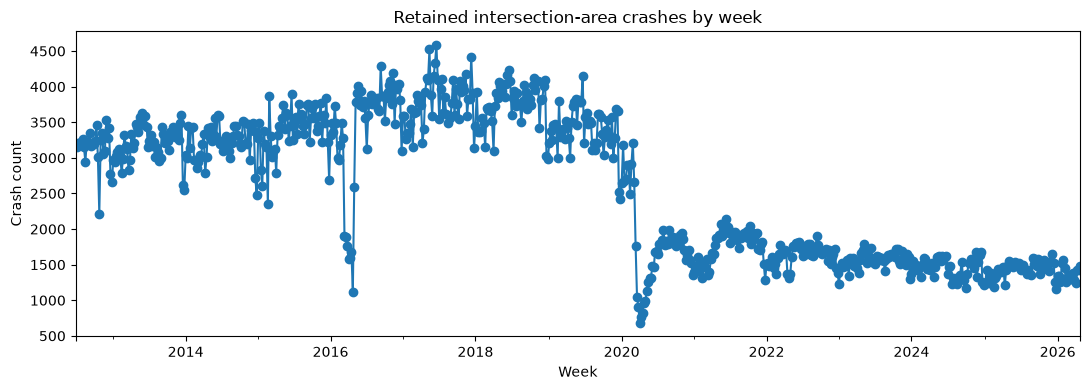

In [16]:
# How many intersection-weeks are positive (crash next week) vs negative,
# and what fraction each makes up — a quick class-balance check.
target_summary = modeling_panel[TARGET_COLUMN].value_counts().sort_index().rename_axis("target").to_frame("rows")

target_summary["fraction"] = target_summary["rows"] / target_summary["rows"].sum()

display(target_summary)

# Total retained crashes per week across all intersections, to visually check
# for trends, seasonality, or data gaps over the analysis period.
weekly_totals = modeling_panel.groupby("week_start", as_index=False)["crash_count"].sum()

# Plot crash counts over time as a simple line chart.
ax = weekly_totals.plot(x="week_start", y="crash_count", figsize=(11, 4), marker="o", legend=False, title="Retained intersection-area crashes by week")
ax.set_xlabel("Week")
ax.set_ylabel("Crash count")
plt.tight_layout()
plt.show()

# 15. Chronological train, validation, and test split

All rows from the same week remain in the same split.

The split evaluates future prediction at previously observed locations. It does not test generalization to completely unseen intersections.

In [17]:
# Get every distinct week in the modeling panel, sorted chronologically --
# the split boundaries below are defined in terms of *weeks*, not rows, so
# that all intersections in a given week land in the same split (no leakage).
unique_weeks = np.array(sorted(modeling_panel["week_start"].unique()))

# Convert the train/validation/test fractions (from the configuration cell)
# into actual week-index cutoffs.
number_of_weeks = len(unique_weeks)

# Guarantee at least 1 week of training data even with a tiny date range.
train_end_index = max(1, int(number_of_weeks * TRAIN_FRACTION))

# Guarantee the validation split gets at least 1 week beyond the training cutoff.
validation_end_index = max(train_end_index + 1, int(number_of_weeks * (TRAIN_FRACTION + VALIDATION_FRACTION)))

# Guarantee at least 1 week is left over for the test split.
validation_end_index = min(validation_end_index, number_of_weeks - 1)

# Slice the sorted week list into three chronological, non-overlapping chunks:
# earliest weeks -> train, middle weeks -> validation, latest weeks -> test.
train_weeks = unique_weeks[:train_end_index]

validation_weeks = unique_weeks[train_end_index:validation_end_index]

test_weeks = unique_weeks[validation_end_index:]

# If the date range is too short, one of the splits could end up empty --
# that would silently break evaluation, so fail loudly instead.
if len(validation_weeks) == 0 or len(test_weeks) == 0:
    raise ValueError("The chronological split produced an empty " "validation or test period.")

# Materialize each split as its own DataFrame by keeping only rows whose week
# falls in that split's set of weeks.
train_data_full = modeling_panel.loc[modeling_panel["week_start"].isin(train_weeks)].copy()

validation_data = modeling_panel.loc[modeling_panel["week_start"].isin(validation_weeks)].copy()

test_data = modeling_panel.loc[modeling_panel["week_start"].isin(test_weeks)].copy()

# --- Downsample zero-crash TRAINING rows only ---
# Keep every positive row and a random fraction of the negatives. This makes training
# several times faster and lighter with little loss, since negatives are abundant.
# Validation and test stay at their true class balance, so the threshold chosen on
# validation and every reported metric reflect real-world prevalence.
train_rows_before_sampling = len(train_data_full)
train_positive_rate_before_sampling = float(train_data_full[TARGET_COLUMN].mean())

sampling_generator = np.random.default_rng(RANDOM_SEED)
keep_row = (train_data_full[TARGET_COLUMN].to_numpy() == 1) | (sampling_generator.random(train_rows_before_sampling) < TRAIN_NEGATIVE_SAMPLE_FRACTION)
train_data = train_data_full.loc[keep_row].copy()
del train_data_full

# Build a small summary table (date range, week count, row count, positive rate)
# for each split, so it's easy to sanity-check the split before modeling.
split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "start": split_frame["week_start"].min(),
            "end": split_frame["week_start"].max(),
            "weeks": split_frame["week_start"].nunique(),
            "rows": len(split_frame),
            "positive_rate": (split_frame[TARGET_COLUMN].mean()),
        }
        for split_name, split_frame in [("train (after negative downsampling)", train_data), ("validation", validation_data), ("test", test_data)]
    ]
)

display(split_summary)
print(f"Training rows before downsampling: {train_rows_before_sampling:,} (positive rate {train_positive_rate_before_sampling:.3%})")
print(f"Training rows after downsampling:  {len(train_data):,} (kept {TRAIN_NEGATIVE_SAMPLE_FRACTION:.0%} of negatives, all positives)")
print("Validation and test were NOT downsampled.")


,split,start,end,weeks,rows,positive_rate
0,train (after negative downsampling),2012-07-02,2022-02-28,505,7479609,0.179775
1,validation,2022-03-07,2024-03-25,108,5537160,0.029172
2,test,2024-04-01,2026-04-27,109,5588430,0.026364


Training rows before downsampling: 25,891,350 (positive rate 5.193%)
Training rows after downsampling:  7,479,609 (kept 25% of negatives, all positives)
Validation and test were NOT downsampled.


# 16. Define model features and preprocessing

In [18]:
# Every numeric column the model is allowed to use as input: static intersection
# attributes, rolling crash/injury history, cyclical seasonality, and weather.
NUMERIC_FEATURES = [
    "latitude",
    "longitude",
    "street_count",
    "is_traffic_signal",
    "is_crossing_tagged",
    "max_connecting_lanes",
    "max_connecting_speed_limit",
    "touches_oneway_street",
    "crashes_last_1w",
    "crashes_last_4w",
    "crashes_last_8w",
    "injuries_last_4w",
    "pedestrian_casualty_crashes_last_8w",
    "cyclist_casualty_crashes_last_8w",
    "weeks_since_last_crash",
    "week_of_year_sin",
    "week_of_year_cos",
] + WEATHER_FEATURES

# Drop any listed feature that doesn't actually exist in this run's panel
# (e.g. a weather feature that wasn't available in the source file).
NUMERIC_FEATURES = [feature for feature in NUMERIC_FEATURES if feature in modeling_panel.columns]

# Non-numeric feature(s) the model will one-hot encode. "road_class" is only
# added if it cleared the completeness threshold in section 8b; if it didn't
# make the cut, it simply won't be a column in modeling_panel and gets dropped
# below like every other feature that fails the missing_features check would.
CATEGORICAL_FEATURES = ["node_highway", "road_class"]
CATEGORICAL_FEATURES = [feature for feature in CATEGORICAL_FEATURES if feature in modeling_panel.columns]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Final safety check: make sure every feature the model expects to use is
# actually present in the panel before slicing out X/y below.
missing_features = [feature for feature in ALL_FEATURES if feature not in modeling_panel.columns]

if missing_features:
    raise ValueError("Missing model features: " + ", ".join(missing_features))

# Build the feature matrix (X) and target vector (y) for each split.
X_train = train_data[ALL_FEATURES]
y_train = train_data[TARGET_COLUMN]

X_validation = validation_data[ALL_FEATURES]
y_validation = validation_data[TARGET_COLUMN]

X_test = test_data[ALL_FEATURES]
y_test = test_data[TARGET_COLUMN]

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)


# Random forest and the MLP scale poorly with rows, so they train on a capped random
# subsample of the (already downsampled) training data. The other models use all of it.
if len(train_data) > SLOW_MODEL_TRAIN_ROWS:
    slow_model_train_data = train_data.sample(SLOW_MODEL_TRAIN_ROWS, random_state=RANDOM_SEED)
else:
    slow_model_train_data = train_data
X_train_slow = slow_model_train_data[ALL_FEATURES]
y_train_slow = slow_model_train_data[TARGET_COLUMN]
print("Rows used for random forest / MLP:", f"{len(X_train_slow):,}")


Numeric features: ['latitude', 'longitude', 'street_count', 'is_traffic_signal', 'is_crossing_tagged', 'touches_oneway_street', 'crashes_last_1w', 'crashes_last_4w', 'crashes_last_8w', 'injuries_last_4w', 'pedestrian_casualty_crashes_last_8w', 'cyclist_casualty_crashes_last_8w', 'weeks_since_last_crash', 'week_of_year_sin', 'week_of_year_cos', 'current_week_mean_temperature_c', 'current_week_total_precipitation_mm', 'current_week_mean_relative_humidity_pct', 'current_week_max_wind_speed_kmh', 'current_week_mean_pressure_hpa']
Categorical features: ['node_highway', 'road_class']
Rows used for random forest / MLP: 1,000,000


In [19]:
# Builds a ColumnTransformer that prepares raw features for modeling:
# numeric columns get missing-value imputation + scaling, categorical columns
# get missing-value imputation + one-hot encoding.
def make_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    # For numeric features: fill any missing value with that column's median,
    # then standardize (mean 0, unit variance) so features are on comparable scales.
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

    # For categorical features: fill missing values with the most common category,
    # then one-hot encode. handle_unknown="ignore" prevents errors if a category
    # shows up at prediction time that wasn't seen during training.
    categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32))])

    # Combine both pipelines, applying each to its respective set of columns.
    # remainder="drop" means any column not listed is simply excluded.
    return ColumnTransformer(
        transformers=[("numeric", numeric_pipeline, numeric_features), ("categorical", categorical_pipeline, categorical_features)], remainder="drop", verbose_feature_names_out=False
    )


# Wraps the preprocessor together with a chosen estimator into one Pipeline,
# so preprocessing and modeling always happen together and can't get out of sync.
# XGBoost's GPU mode requires an NVIDIA/CUDA build. On an AMD GPU (e.g. Radeon RX 9060 XT) it
# cannot be used, so run on the CPU. The 6-core CPU handles the "hist" tree method well.
XGB_DEVICE = "cpu"
print("XGBoost device:", XGB_DEVICE)


def make_model_pipeline(model_name: str, numeric_features: list[str], categorical_features: list[str], y_train_labels=None) -> Pipeline:
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    # class_weight="balanced" upweights the minority (crash) class automatically,
    # since crash-next-week is a relatively rare event.
    if model_name == "logistic_regression":
        estimator = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)

    # min_samples_leaf=5 and class_weight="balanced_subsample" reduce overfitting
    # to noisy individual intersections while still respecting class imbalance.
    elif model_name == "random_forest":
        estimator = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, min_samples_leaf=5, class_weight="balanced_subsample", random_state=RANDOM_SEED, n_jobs=-1)

    # scale_pos_weight approximates class_weight="balanced" for XGBoost, since
    # it has no built-in "balanced" option like sklearn's estimators do.
    elif model_name == "xgboost":
        positive_weight = (y_train_labels == 0).sum() / max((y_train_labels == 1).sum(), 1)
        estimator = XGBClassifier(
            n_estimators=XGB_N_ESTIMATORS,
            tree_method="hist",
            device=XGB_DEVICE,
            scale_pos_weight=positive_weight,
            eval_metric="aucpr",
            random_state=RANDOM_SEED,
        )

    # LightGBM has its own "is_unbalance" flag that plays the same role as
    # scale_pos_weight above — it upweights the rare positive class.
    elif model_name == "lightgbm":
        estimator = LGBMClassifier(
            n_estimators=LGBM_N_ESTIMATORS,
            is_unbalance=True,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    # A small neural network. Unlike the tree models, MLPClassifier has no
    # built-in class-weighting option, so class imbalance is instead handled
    # by choosing a good decision threshold afterward (same as every other
    # model here) rather than during training.
    elif model_name == "mlp":
        estimator = MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-3,
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_SEED,
        )

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    return Pipeline([("preprocess", preprocessor), ("model", estimator)])

XGBoost device: cpu


# 17. Evaluation utilities

In [20]:
# Wraps a scikit-learn probability-based metric (like ROC-AUC) so that if it
# can't be computed (e.g. only one class present in y_true), the function
# returns NaN instead of crashing the whole notebook.
def safe_probability_metric(metric_function, y_true, probability) -> float:
    try:
        return float(metric_function(y_true, probability))
    except ValueError:
        return np.nan


# Computes a broad set of classification metrics at a given probability
# threshold, bundled into one dictionary for easy comparison across models.
def classification_metrics(y_true, probability, threshold: float) -> dict[str, Any]:
    # Convert continuous predicted probabilities into hard 0/1 predictions by
    # comparing against the chosen threshold.
    prediction = (np.asarray(probability) >= threshold).astype(int)

    # Break the confusion matrix into its four named quadrants for easy reuse below.
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()

    # Fraction of rows that are actually positive — used as a naive baseline for
    # Average Precision (a model no better than guessing the base rate scores ~this).
    positive_rate = float(np.mean(y_true))

    average_precision = safe_probability_metric(average_precision_score, y_true, probability)

    # "Lift" = how many times better than the naive base-rate baseline the model's
    # Average Precision is. A lift of 1 means no better than guessing; higher is better.
    average_precision_lift = average_precision / positive_rate if positive_rate > 0 and np.isfinite(average_precision) else np.nan

    return {
        "threshold": float(threshold),
        "positive_rate": positive_rate,
        "precision": float(precision_score(y_true, prediction, zero_division=0)),
        "recall": float(recall_score(y_true, prediction, zero_division=0)),
        "f1": float(f1_score(y_true, prediction, zero_division=0)),
        "f2": float(fbeta_score(y_true, prediction, beta=THRESHOLD_BETA, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, prediction)),
        "roc_auc": safe_probability_metric(roc_auc_score, y_true, probability),
        "average_precision": average_precision,
        "average_precision_lift": (float(average_precision_lift) if np.isfinite(average_precision_lift) else np.nan),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


# Ranks every row by predicted probability and checks what fraction of the
# actual crash-positive rows fall inside the top k% of that ranking. This is
# the "if we only had time to inspect the riskiest k% of locations, how much
# of the real problem would we catch" metric — more intuitive to explain than
# a probability threshold, and it mirrors how a resource-limited city would
# actually use these rankings.
def top_k_hotspot_recovery(y_true, probability, k_fraction: float) -> float:
    y_true = np.asarray(y_true)
    probability = np.asarray(probability)

    total_positive = int(y_true.sum())
    if total_positive == 0:
        return np.nan

    # Number of rows in the top k% of the ranking (at least 1 row).
    top_k_count = max(1, int(np.ceil(k_fraction * len(probability))))

    # Indices of the top_k_count highest predicted-probability rows.
    top_k_indices = np.argsort(probability)[::-1][:top_k_count]

    positives_in_top_k = int(y_true[top_k_indices].sum())

    return positives_in_top_k / total_positive


# Finds the probability threshold that maximizes the F-beta score (beta from THRESHOLD_BETA,
# favoring recall). Uses ONE precision-recall curve, which evaluates every distinct predicted
# score in O(n log n). The earlier version called scikit-learn once per candidate threshold,
# which is fine for ~50k rows but would run for days on millions of validation rows.
# Returns the best threshold plus a table of precision/recall/F-beta across thresholds
# (thinned to at most `max_table_rows` rows, for plotting).
def find_best_fbeta_threshold(y_true, probability, beta: float = 2.0, max_table_rows: int = 3000) -> tuple[float, pd.DataFrame]:
    y_true = np.asarray(y_true)
    probability = np.asarray(probability, dtype=float)

    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    # precision/recall have one more entry than thresholds (the "no predictions" endpoint); drop it.
    precision, recall = precision[:-1], recall[:-1]

    in_range = (thresholds >= 0.0) & (thresholds <= 1.0)
    thresholds, precision, recall = thresholds[in_range], precision[in_range], recall[in_range]

    beta_squared = beta**2
    denominator = beta_squared * precision + recall
    fbeta = np.divide((1 + beta_squared) * precision * recall, denominator, out=np.zeros_like(denominator), where=denominator > 0)

    # Best F-beta, breaking ties by higher recall then higher precision (last key is primary).
    best_index = int(np.lexsort((precision, recall, fbeta))[-1])

    keep = np.unique(np.concatenate([np.linspace(0, len(thresholds) - 1, min(max_table_rows, len(thresholds))).astype(int), [best_index]]))
    threshold_table = pd.DataFrame({"threshold": thresholds[keep], "precision": precision[keep], "recall": recall[keep], "fbeta": fbeta[keep]})

    return (float(thresholds[best_index]), threshold_table)


# 18. Historical heuristic baseline

In [21]:
# A simple, non-ML baseline: "predict a crash next week if there was at least
# one crash in the last 4 weeks." Used as a sanity-check floor the trained
# models should beat.
heuristic_validation_probability = (validation_data["crashes_last_4w"] > 0).astype(float).to_numpy()

heuristic_validation_metrics = classification_metrics(y_validation, heuristic_validation_probability, threshold=0.5)

display(pd.Series(heuristic_validation_metrics, name="historical_4week_heuristic").to_frame())

,historical_4week_heuristic
threshold,5.000000e-01
positive_rate,2.917181e-02
precision,8.481889e-02
recall,2.962378e-01
f1,1.318783e-01
f2,1.976871e-01
balanced_accuracy,6.000963e-01
roc_auc,6.000963e-01
average_precision,4.565658e-02
average_precision_lift,1.565092e+00


# 19. Train logistic regression

In [22]:
# Build and train a logistic regression pipeline on the training split.
logistic_model = make_model_pipeline("logistic_regression", NUMERIC_FEATURES, CATEGORICAL_FEATURES)

logistic_model.fit(X_train, y_train)

# Predicted probability of "crash next week" for every validation-split row.
logistic_validation_probability = logistic_model.predict_proba(X_validation)[:, 1]

(
    # Pick the best decision threshold using only the validation set (never test).
    logistic_threshold,
    logistic_threshold_table,
) = find_best_fbeta_threshold(y_validation, logistic_validation_probability, beta=THRESHOLD_BETA)

# Score the model at that chosen threshold.
logistic_validation_metrics = classification_metrics(y_validation, logistic_validation_probability, logistic_threshold)

print("Selected logistic threshold:", round(logistic_threshold, 4))

display(pd.Series(logistic_validation_metrics, name="logistic_regression").to_frame())

Selected logistic threshold: 0.5701


,logistic_regression
threshold,5.700986e-01
positive_rate,2.917181e-02
precision,8.690694e-02
recall,5.142730e-01
f1,1.486872e-01
f2,2.592752e-01
balanced_accuracy,6.759572e-01
roc_auc,7.831972e-01
average_precision,1.078312e-01
average_precision_lift,3.696419e+00


# 19b. Train XGBoost

In [23]:
# Train XGBoost, following the exact same procedure as logistic regression
# above: fit on train, get validation probabilities, pick the best threshold
# on validation only, then score at that threshold.
xgboost_model = make_model_pipeline("xgboost", NUMERIC_FEATURES, CATEGORICAL_FEATURES, y_train)

xgboost_model.fit(X_train, y_train)

# Predicted probability of "crash next week" for every validation-split row.
xgboost_validation_probability = xgboost_model.predict_proba(X_validation)[:, 1]

(
    # Pick the best decision threshold using only the validation set (never test).
    xgboost_threshold,
    xgboost_threshold_table,
) = find_best_fbeta_threshold(y_validation, xgboost_validation_probability, beta=THRESHOLD_BETA)

# Score the model at that chosen threshold.
xgboost_validation_metrics = classification_metrics(y_validation, xgboost_validation_probability, xgboost_threshold)

print("Selected XGBoost threshold:", round(xgboost_threshold, 4))

display(pd.Series(xgboost_validation_metrics, name="xgboost").to_frame())

Selected XGBoost threshold: 0.596


,xgboost
threshold,5.960079e-01
positive_rate,2.917181e-02
precision,8.952226e-02
recall,5.339413e-01
f1,1.533358e-01
f2,2.679260e-01
balanced_accuracy,6.853833e-01
roc_auc,7.912797e-01
average_precision,1.154097e-01
average_precision_lift,3.956205e+00


# 19c. Train LightGBM

In [24]:
# Train LightGBM, following the same fit / validation-probability / threshold
# / score procedure as every other model in this notebook.
lightgbm_model = make_model_pipeline("lightgbm", NUMERIC_FEATURES, CATEGORICAL_FEATURES)

lightgbm_model.fit(X_train, y_train)

lightgbm_validation_probability = lightgbm_model.predict_proba(X_validation)[:, 1]

(
    lightgbm_threshold,
    lightgbm_threshold_table,
) = find_best_fbeta_threshold(y_validation, lightgbm_validation_probability, beta=THRESHOLD_BETA)

lightgbm_validation_metrics = classification_metrics(y_validation, lightgbm_validation_probability, lightgbm_threshold)

print("Selected LightGBM threshold:", round(lightgbm_threshold, 4))

display(pd.Series(lightgbm_validation_metrics, name="lightgbm").to_frame())

Selected LightGBM threshold: 0.5833


,lightgbm
threshold,5.833219e-01
positive_rate,2.917181e-02
precision,8.693069e-02
recall,5.434566e-01
f1,1.498858e-01
f2,2.650592e-01
balanced_accuracy,6.859679e-01
roc_auc,7.898477e-01
average_precision,1.141012e-01
average_precision_lift,3.911351e+00


# 19d. Train neural network (MLP)

In [25]:
# Train the MLP (neural network) model, same procedure as the other models.
# Unlike the tree models, MLPClassifier is sensitive to unscaled inputs, but
# that's already handled: make_preprocessor() standardizes numeric features
# for every model, including this one.
mlp_model = make_model_pipeline("mlp", NUMERIC_FEATURES, CATEGORICAL_FEATURES)

mlp_model.fit(X_train_slow, y_train_slow)

mlp_validation_probability = mlp_model.predict_proba(X_validation)[:, 1]

(
    mlp_threshold,
    mlp_threshold_table,
) = find_best_fbeta_threshold(y_validation, mlp_validation_probability, beta=THRESHOLD_BETA)

mlp_validation_metrics = classification_metrics(y_validation, mlp_validation_probability, mlp_threshold)

print("Selected MLP threshold:", round(mlp_threshold, 4))

display(pd.Series(mlp_validation_metrics, name="mlp").to_frame())

Selected MLP threshold: 0.2412


,mlp
threshold,2.412369e-01
positive_rate,2.917181e-02
precision,8.704220e-02
recall,5.310502e-01
f1,1.495691e-01
f2,2.628684e-01
balanced_accuracy,6.818401e-01
roc_auc,7.860138e-01
average_precision,1.109758e-01
average_precision_lift,3.804212e+00


# 20. (Optional) Train random forest — CPU-only comparison

In [26]:
# Optional CPU-only comparison against logistic regression and XGBoost.
# Same procedure as the logistic regression cell above, but with a random forest.
random_forest_model = make_model_pipeline("random_forest", NUMERIC_FEATURES, CATEGORICAL_FEATURES)

random_forest_model.fit(X_train_slow, y_train_slow)

forest_validation_probability = random_forest_model.predict_proba(X_validation)[:, 1]

forest_threshold, forest_threshold_table = find_best_fbeta_threshold(y_validation, forest_validation_probability, beta=THRESHOLD_BETA)

forest_validation_metrics = classification_metrics(y_validation, forest_validation_probability, forest_threshold)

print("Selected random-forest threshold:", round(forest_threshold, 4))

display(pd.Series(forest_validation_metrics, name="random_forest").to_frame())

Selected random-forest threshold: 0.4736


,random_forest
threshold,4.736404e-01
positive_rate,2.917181e-02
precision,8.771351e-02
recall,5.213243e-01
f1,1.501620e-01
f2,2.621435e-01
balanced_accuracy,6.791985e-01
roc_auc,7.851881e-01
average_precision,1.093166e-01
average_precision_lift,3.747338e+00


# 21. Select the baseline model using validation results

Average Precision is the primary selection metric because the positive class is uncommon. F2 is used as the secondary metric.

The test set remains untouched during this decision.

In [27]:
# Line up every candidate (heuristic baseline + all trained models) side by
# side, ranked by validation Average Precision (tie-broken by F2).
validation_comparison = pd.DataFrame(
    [
        {"model": "historical_4week_heuristic", **heuristic_validation_metrics},
        {"model": "logistic_regression", **logistic_validation_metrics},
        {"model": "xgboost", **xgboost_validation_metrics},
        {"model": "lightgbm", **lightgbm_validation_metrics},
        {"model": "mlp", **mlp_validation_metrics},
        {"model": "random_forest", **forest_validation_metrics},
    ]
).sort_values(["average_precision", "f2"], ascending=False, na_position="last")

display(validation_comparison)

# Keep each trained model's pipeline, chosen threshold, and validation
# probabilities together so the winner can be looked up by name below.
model_registry = {
    "logistic_regression": {"pipeline": logistic_model, "threshold": logistic_threshold, "validation_probability": (logistic_validation_probability)},
    "xgboost": {"pipeline": xgboost_model, "threshold": xgboost_threshold, "validation_probability": (xgboost_validation_probability)},
    "lightgbm": {"pipeline": lightgbm_model, "threshold": lightgbm_threshold, "validation_probability": (lightgbm_validation_probability)},
    "mlp": {"pipeline": mlp_model, "threshold": mlp_threshold, "validation_probability": (mlp_validation_probability)},
    "random_forest": {"pipeline": random_forest_model, "threshold": forest_threshold, "validation_probability": (forest_validation_probability)},
}

# Only actual trained models are eligible to be "selected" (the heuristic
# baseline is for comparison only, not for deployment).
eligible_models = validation_comparison.loc[validation_comparison["model"].isin(model_registry)]

# Because validation_comparison is already sorted best-first, the top eligible
# row is the winning model.
selected_model_name = eligible_models.iloc[0]["model"]

selected_model = model_registry[selected_model_name]["pipeline"]

selected_threshold = float(model_registry[selected_model_name]["threshold"])

selected_validation_probability = model_registry[selected_model_name]["validation_probability"]

print("Selected model:", selected_model_name)
print("Selected threshold:", round(selected_threshold, 4))

,model,threshold,positive_rate,precision,recall,f1,f2,balanced_accuracy,roc_auc,average_precision,average_precision_lift,brier_score,true_negative,false_positive,false_negative,true_positive
2,xgboost,0.596008,0.029172,0.089522,0.533941,0.153336,0.267926,0.685383,0.791280,0.115410,3.956205,0.156228,4498464,877167,75282,86247
3,lightgbm,0.583322,0.029172,0.086931,0.543457,0.149886,0.265059,0.685968,0.789848,0.114101,3.911351,0.153486,4453599,922032,73745,87784
4,mlp,0.241237,0.029172,0.087042,0.531050,0.149569,0.262868,0.681840,0.786014,0.110976,3.804212,0.044778,4475912,899719,75749,85780
5,random_forest,0.473640,0.029172,0.087714,0.521324,0.150162,0.262144,0.679199,0.785188,0.109317,3.747338,0.107472,4499794,875837,77320,84209
1,logistic_regression,0.570099,0.029172,0.086907,0.514273,0.148687,0.259275,0.675957,0.783197,0.107831,3.696419,0.152008,4502851,872780,78459,83070
0,historical_4week_heuristic,0.500000,0.029172,0.084819,0.296238,0.131878,0.197687,0.600096,0.600096,0.045657,1.565092,0.113773,4859327,516304,113678,47851


Selected model: xgboost
Selected threshold: 0.596


# 21b. Comprehensive model comparison analytics

The single-number comparison above (Average Precision, F2, etc.) is useful for ranking models, but hides *how* each model earns its score. The cells below add three complementary views, all computed on the validation split only (never test): full ROC/precision-recall curve shapes for every model, a side-by-side bar chart of the key rare-event metrics, and top-k hotspot recovery — the most app-relevant metric, since it mirrors a city only having the resources to inspect a limited number of locations.

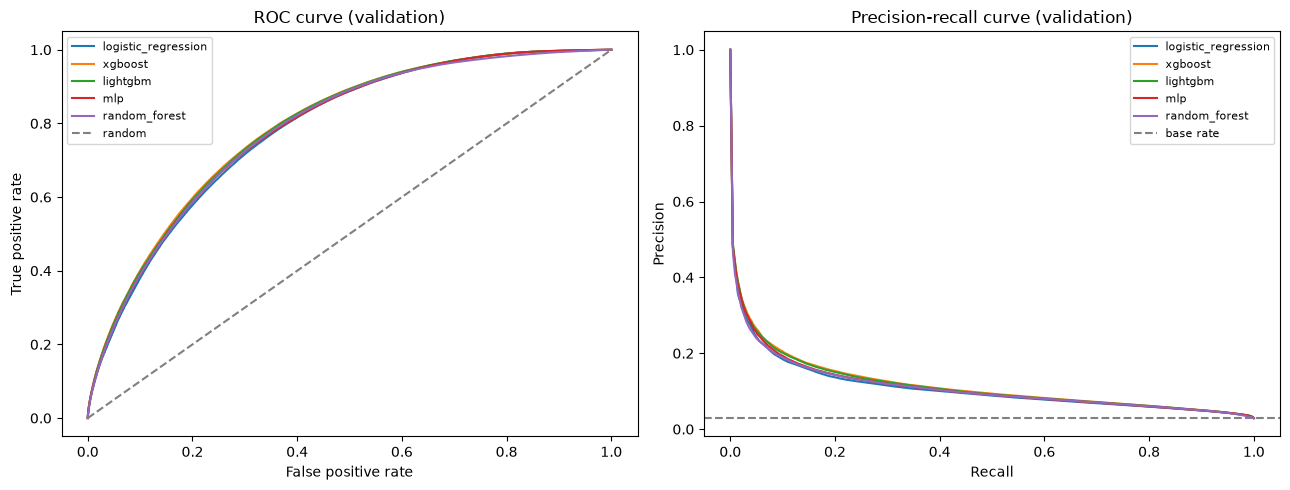

In [28]:
# Overlay ROC and precision-recall curves for every trained model on the same
# validation data, so their shapes can be compared directly at a glance rather
# than only via single summary numbers.
from sklearn.metrics import roc_curve

fig, (roc_ax, pr_ax) = plt.subplots(1, 2, figsize=(13, 5))

for model_name, model_info in model_registry.items():
    probability = model_info["validation_probability"]

    false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, probability)
    roc_ax.plot(false_positive_rate, true_positive_rate, label=model_name)

    precision_values, recall_values, _ = precision_recall_curve(y_validation, probability)
    # Thin the curve: at millions of rows it has millions of points; ~3,000 look identical.
    thin = np.unique(np.linspace(0, len(recall_values) - 1, 3000).astype(int))
    pr_ax.plot(recall_values[thin], precision_values[thin], label=model_name)

roc_ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random")
roc_ax.set_xlabel("False positive rate")
roc_ax.set_ylabel("True positive rate")
roc_ax.set_title("ROC curve (validation)")
roc_ax.legend(fontsize=8)

validation_positive_rate = float(y_validation.mean())
pr_ax.axhline(validation_positive_rate, linestyle="--", color="grey", label="base rate")
pr_ax.set_xlabel("Recall")
pr_ax.set_ylabel("Precision")
pr_ax.set_title("Precision-recall curve (validation)")
pr_ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

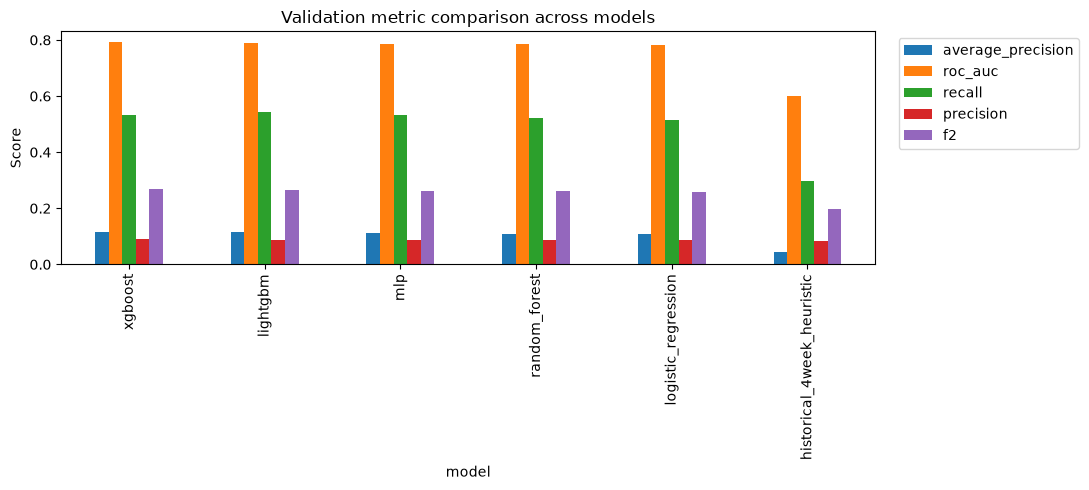

In [29]:
# Bar chart comparing the key rare-event metrics side by side across every
# trained model, so the tradeoffs between models are visible at once instead
# of scanning a wide table.
comparison_metric_columns = ["average_precision", "roc_auc", "recall", "precision", "f2"]

chart_data = validation_comparison.set_index("model")[comparison_metric_columns]

ax = chart_data.plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("Score")
ax.set_title("Validation metric comparison across models")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [30]:
# Top-k hotspot recovery, computed on the validation split, for every trained
# model at a few review-budget sizes (5%, 10%, 20% of locations reviewed).
HOTSPOT_K_FRACTIONS = [0.05, 0.10, 0.20]

hotspot_recovery_rows = []

for model_name, model_info in model_registry.items():
    row = {"model": model_name}
    for k_fraction in HOTSPOT_K_FRACTIONS:
        column_name = f"top_{int(k_fraction * 100)}pct_recovery"
        row[column_name] = top_k_hotspot_recovery(y_validation, model_info["validation_probability"], k_fraction)
    hotspot_recovery_rows.append(row)

hotspot_recovery_table = pd.DataFrame(hotspot_recovery_rows).sort_values("top_10pct_recovery", ascending=False)

print("Example: for the selected model, reviewing the top 10% of ranked")
print("intersection-weeks would have caught this fraction of next-week crashes:")
display(hotspot_recovery_table)

Example: for the selected model, reviewing the top 10% of ranked
intersection-weeks would have caught this fraction of next-week crashes:


,model,top_5pct_recovery,top_10pct_recovery,top_20pct_recovery
1,xgboost,0.240972,0.379486,0.578825
2,lightgbm,0.237734,0.376527,0.574002
3,mlp,0.230782,0.369506,0.568783
4,random_forest,0.229853,0.369506,0.568282
0,logistic_regression,0.222771,0.360301,0.560525


## Validation threshold tradeoff

This graph is for understanding the validation-stage precision-recall tradeoff. It must not be used to retune the threshold after examining the final test results.

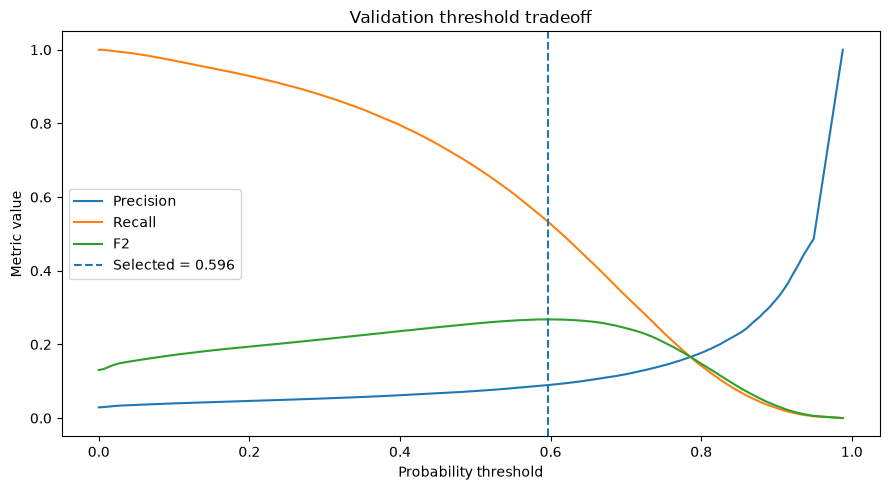

In [31]:
# Reuse whichever model's full threshold sweep table corresponds to the winner,
# so the tradeoff plot below reflects the model actually being used.
threshold_tables = {
    "logistic_regression": logistic_threshold_table,
    "xgboost": xgboost_threshold_table,
    "lightgbm": lightgbm_threshold_table,
    "mlp": mlp_threshold_table,
    "random_forest": forest_threshold_table,
}
selected_threshold_table = threshold_tables[selected_model_name]

# Plot precision, recall, and F-beta across every threshold tried, with a
# vertical line marking the threshold that was actually selected.
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(selected_threshold_table["threshold"], selected_threshold_table["precision"], label="Precision")

ax.plot(selected_threshold_table["threshold"], selected_threshold_table["recall"], label="Recall")

ax.plot(selected_threshold_table["threshold"], selected_threshold_table["fbeta"], label=f"F{THRESHOLD_BETA:g}")

ax.axvline(selected_threshold, linestyle="--", label=f"Selected = {selected_threshold:.3f}")

ax.set_title("Validation threshold tradeoff")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Metric value")
ax.legend()

plt.tight_layout()
plt.show()

# 22. Development-stage ablation tests

These experiments are evaluated on the validation period, not the final test period. They test whether the selected model depends heavily on:

- Latitude and longitude
- Recent crash-history variables
- Weather summaries

A large decline after removing coordinates would suggest spatial hotspot dependence. A large decline after removing crash history would suggest temporal persistence dependence.

In [32]:
# Feature groups to test removing, one at a time, to see how much each
# contributes to validation performance.
COORDINATE_FEATURES = ["latitude", "longitude"]

HISTORY_FEATURES = ["crashes_last_1w", "crashes_last_4w", "crashes_last_8w", "injuries_last_4w", "pedestrian_casualty_crashes_last_8w", "cyclist_casualty_crashes_last_8w", "weeks_since_last_crash"]


# Retrains the selected model architecture with a given set of features
# removed, then evaluates it on validation data the same way as the full model —
# so results are directly comparable.
def run_validation_ablation(experiment_name: str, removed_numeric_features: list[str]) -> dict[str, Any]:
    # Keep every numeric feature except the ones being ablated for this experiment.
    experiment_numeric_features = [feature for feature in NUMERIC_FEATURES if feature not in removed_numeric_features]

    experiment_features = experiment_numeric_features + CATEGORICAL_FEATURES

    experiment_model = make_model_pipeline(selected_model_name, experiment_numeric_features, CATEGORICAL_FEATURES,y_train)

    experiment_model.fit(train_data[experiment_features], y_train)

    experiment_probability = experiment_model.predict_proba(validation_data[experiment_features])[:, 1]

    experiment_threshold, _ = find_best_fbeta_threshold(y_validation, experiment_probability, beta=THRESHOLD_BETA)

    experiment_metrics = classification_metrics(y_validation, experiment_probability, experiment_threshold)

    return {"experiment": experiment_name, "removed_features": ", ".join(removed_numeric_features), "feature_count": len(experiment_features), **experiment_metrics}


# Baseline row: the full model's own validation metrics, for comparison against
# each ablated version below.
selected_validation_metrics = classification_metrics(y_validation, selected_validation_probability, selected_threshold)

# Run the full model plus one ablation per feature group (coordinates, crash
# history, weather) and collect all results into one comparison table.
ablation_results = [
    {"experiment": "full_selected_model", "removed_features": "", "feature_count": len(ALL_FEATURES), **selected_validation_metrics},
    run_validation_ablation("without_coordinates", COORDINATE_FEATURES),
    run_validation_ablation("without_crash_history", HISTORY_FEATURES),
    run_validation_ablation("without_weather", WEATHER_FEATURES),
]

ablation_table = pd.DataFrame(ablation_results)

display(ablation_table[["experiment", "feature_count", "threshold", "precision", "recall", "f2", "average_precision", "average_precision_lift", "brier_score"]])

,experiment,feature_count,threshold,precision,recall,f2,average_precision,average_precision_lift,brier_score
0,full_selected_model,22,0.596008,0.089522,0.533941,0.267926,0.115410,3.956205,0.156228
1,without_coordinates,20,0.580104,0.085059,0.531564,0.259316,0.110333,3.782178,0.152568
2,without_crash_history,15,0.590482,0.074723,0.523225,0.237781,0.085239,2.921955,0.191617
3,without_weather,17,0.605735,0.091778,0.531025,0.271319,0.117304,4.021134,0.159089


### Ablation interpretation prompts

1. How much did Average Precision change without coordinates?
2. How much did it change without crash history?
3. Did weather add meaningful validation performance?
4. Is the selected model primarily learning hotspot persistence, roadway context, temporal context, or a combination?
5. Which conclusion is supported by the results, and which conclusion would be too strong?

# 23. Lock the model and evaluate the final test period once

The selected pipeline and threshold were determined using training and validation data. They are now applied to the test period without adjustment.

In [33]:
# Run the locked-in model on the held-out test split, which has not been
# touched until now (not used for training, threshold tuning, or model selection).
test_probability = selected_model.predict_proba(X_test)[:, 1]

# Apply the validation-selected threshold to get hard predictions on test data.
test_prediction = (test_probability >= selected_threshold).astype(int)

# One-time, final performance readout on the test set.
test_metrics = classification_metrics(y_test, test_probability, selected_threshold)

display(pd.Series(test_metrics, name=f"{selected_model_name}_test").to_frame())

,xgboost_test
threshold,5.960079e-01
positive_rate,2.636411e-02
precision,7.917636e-02
recall,5.049819e-01
f1,1.368897e-01
f2,2.432959e-01
balanced_accuracy,6.729770e-01
roc_auc,7.765052e-01
average_precision,9.806347e-02
average_precision_lift,3.719582e+00


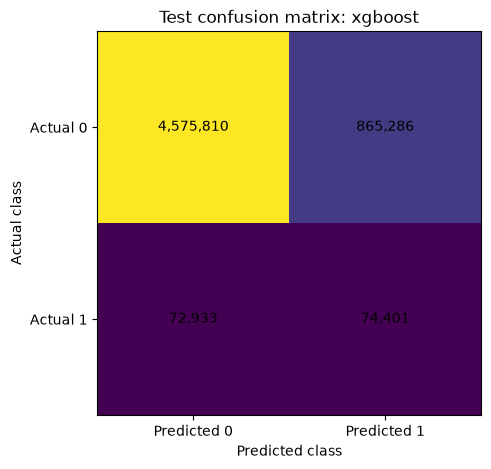

In [34]:
# Build the 2x2 confusion matrix (actual class x predicted class) on test data.
test_confusion_matrix = confusion_matrix(y_test, test_prediction, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(test_confusion_matrix)

# Overlay the raw count in each of the four confusion-matrix cells as text.
for row_index in range(2):
    for column_index in range(2):
        ax.text(column_index, row_index, f"{test_confusion_matrix[row_index, column_index]:,}", ha="center", va="center")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])
ax.set_title(f"Test confusion matrix: {selected_model_name}")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

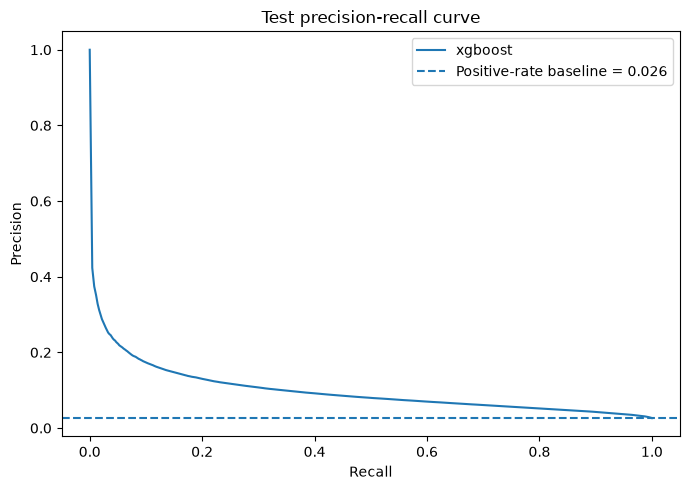

In [35]:
# Precision and recall at every possible threshold, for plotting the full
# precision-recall tradeoff curve (the underscore discards the threshold array).
precision_values, recall_values, _ = precision_recall_curve(y_test, test_probability)

# The naive base-rate baseline for this test set, to visually compare against
# the model's curve.
test_positive_rate = float(y_test.mean())

fig, ax = plt.subplots(figsize=(7, 5))

thin = np.unique(np.linspace(0, len(recall_values) - 1, 3000).astype(int))
ax.plot(recall_values[thin], precision_values[thin], label=selected_model_name)

ax.axhline(test_positive_rate, linestyle="--", label=("Positive-rate baseline = " f"{test_positive_rate:.3f}"))

ax.set_title("Test precision-recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.show()

# 24. Save and verify the fitted model, metadata, metrics, and predictions

This is the missing persistence step that caused the earlier Notebook 3 dependency problem.

The notebook:

1. Saves the selected fitted pipeline.
2. Saves metadata describing the exact model and split.
3. Saves predictions and metrics.
4. Reloads the model immediately.
5. Confirms that the reloaded model produces identical probabilities.

In [36]:
# File paths for everything this cell will persist to disk: the trained
# pipeline, its metadata, row-level test predictions, and summary metric tables.
MODEL_PATH = MODEL_DIR / "safecross_baseline_pipeline.joblib"

MODEL_METADATA_PATH = MODEL_DIR / "safecross_baseline_metadata.json"

TEST_PREDICTION_PATH = DATA_PROCESSED_DIR / "safecross_test_predictions.parquet"

VALIDATION_METRICS_PATH = METRIC_DIR / "validation_model_comparison.csv"

TEST_METRICS_PATH = METRIC_DIR / "selected_model_test_metrics.json"

ABLATION_PATH = METRIC_DIR / "validation_ablation_comparison.csv"

# Keep a compact, useful set of columns alongside the predictions rather than
# every column in test_data.
# Includes every model feature (not just a handful), plus identifying columns.
# This is what lets Notebook 3 run standalone later — reloading this file
# gives it everything it needs (calibration, importance, subgroup analysis,
# mapping, the app table) without re-running Notebook 1 or Notebook 2.
prediction_columns = list(dict.fromkeys(["node_id", "week_start"] + ALL_FEATURES + [TARGET_COLUMN]))

# Build the row-level prediction export: identifying/context columns plus the
# model's predicted probability and hard class for each test row.
test_predictions = test_data[prediction_columns].copy()

test_predictions["predicted_probability"] = test_probability

test_predictions["predicted_class"] = test_prediction

# Save predictions, validation comparison, and ablation results to disk.
test_predictions.to_parquet(TEST_PREDICTION_PATH, index=False)

validation_comparison.to_csv(VALIDATION_METRICS_PATH, index=False)

ablation_table.to_csv(ABLATION_PATH, index=False)

with open(
    # allow_nan=True lets NaN metric values (e.g. an undefined ROC-AUC) serialize
    # instead of raising an error.
    TEST_METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(test_metrics, file, indent=2, allow_nan=True)

# Serialize the fitted pipeline (preprocessing + model) so it can be reloaded
# later without retraining.
joblib.dump(selected_model, MODEL_PATH)

# A structured record of exactly how this model was built: which features,
# which date ranges went into each split, and key configuration values —
# useful for reproducing or auditing this run later.
metadata = {
    "selected_model": selected_model_name,
    "selected_threshold": selected_threshold,
    "target": TARGET_COLUMN,
    "prediction_unit": ("eligible OSM intersection node by week"),
    "prediction_horizon": "following week",
    "feature_timing": ("week t features predict week t+1"),
    "weather_timing": ("weather observed during week t"),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": (CATEGORICAL_FEATURES),
    "training_start": str(train_data["week_start"].min().date()),
    "training_end": str(train_data["week_start"].max().date()),
    "validation_start": str(validation_data["week_start"].min().date()),
    "validation_end": str(validation_data["week_start"].max().date()),
    "test_start": str(test_data["week_start"].min().date()),
    "test_end": str(test_data["week_start"].max().date()),
    "analysis_start": str(analysis_start.date()),
    "analysis_end": str(analysis_end.date()),
    "random_seed": RANDOM_SEED,
    "train_negative_sample_fraction": TRAIN_NEGATIVE_SAMPLE_FRACTION,
    "train_rows_before_negative_sampling": int(train_rows_before_sampling),
    "train_rows_used": int(len(train_data)),
    "validation_and_test_downsampled": False,
    "slow_model_train_rows_cap": SLOW_MODEL_TRAIN_ROWS,
    "node_match_distance_m": (MAX_NODE_MATCH_DISTANCE_M),
    "minimum_street_count": (CANDIDATE_MIN_STREET_COUNT),
    "sklearn_version": sklearn.__version__,
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved metadata:", MODEL_METADATA_PATH)
print("Saved predictions:", TEST_PREDICTION_PATH)
print("Saved validation metrics:", VALIDATION_METRICS_PATH)
print("Saved test metrics:", TEST_METRICS_PATH)

Saved model: c:\Users\j9936\Desktop\Capstone\noteboooks\models\safecross_baseline_pipeline.joblib
Saved metadata: c:\Users\j9936\Desktop\Capstone\noteboooks\models\safecross_baseline_metadata.json
Saved predictions: c:\Users\j9936\Desktop\Capstone\noteboooks\data\processed\safecross_test_predictions.parquet
Saved validation metrics: c:\Users\j9936\Desktop\Capstone\noteboooks\reports\metrics\validation_model_comparison.csv
Saved test metrics: c:\Users\j9936\Desktop\Capstone\noteboooks\reports\metrics\selected_model_test_metrics.json


In [37]:
# Load the just-saved model and metadata back from disk, as an end-to-end
# check that the save actually worked correctly.
reloaded_model = joblib.load(MODEL_PATH)

with open(MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
    reloaded_metadata = json.load(file)

# Re-run predictions with the reloaded model on the same test features.
reloaded_probability = reloaded_model.predict_proba(X_test)[:, 1]

# The reloaded model's predictions should be numerically identical (up to
# floating-point noise) to the original in-memory model's predictions.
maximum_probability_difference = float(np.max(np.abs(reloaded_probability - test_probability)))

# Confirm the metadata correctly records which model was selected.
assert reloaded_metadata["selected_model"] == selected_model_name

# Confirm the reloaded model reproduces the original predictions essentially exactly.
assert maximum_probability_difference < 1e-12

print("Artifact verification passed.")
print("Maximum probability difference:", maximum_probability_difference)

Artifact verification passed.
Maximum probability difference: 0.0


# 34. Leakage and reproducibility audit

In [38]:
# Confirm the chronological splits never overlap in time (no week appears
# in more than one split) — a core defense against data leakage.
assert train_data["week_start"].max() < validation_data["week_start"].min()

assert validation_data["week_start"].max() < test_data["week_start"].min()

# Confirm the target itself, the raw next-week count it was derived from, and
# the raw event ID were never accidentally included as model input features.
assert TARGET_COLUMN not in X_train.columns
assert "next_week_crash_count" not in X_train.columns
assert "collision_id" not in X_train.columns

# Re-confirm zero-crash weeks are still present in the final modeling panel.
assert (modeling_panel["crash_count"] == 0).any()

# Confirm every split's target values are strictly binary.
assert set(y_train.unique()).issubset({0, 1})

assert set(y_validation.unique()).issubset({0, 1})

assert set(y_test.unique()).issubset({0, 1})

# Confirm the expected output artifacts were actually written to disk.
assert MODEL_PATH.exists()
assert MODEL_METADATA_PATH.exists()
assert TEST_PREDICTION_PATH.exists()

print("Leakage, split, artifact, and " "reproducibility checks passed.")

# Confirm only the training split was downsampled: validation and test must contain every
# intersection-week in their weeks.
assert len(validation_data) == N_NODES * len(validation_weeks)
assert len(test_data) == N_NODES * len(test_weeks)
print("Validation and test contain every intersection-week (no downsampling).")


Leakage, split, artifact, and reproducibility checks passed.
Validation and test contain every intersection-week (no downsampling).
